### Tesouro Direto EDA

Bonds:
- ntnb: Tesouro IPCA+. Input for real yeald curve
- ntnb_coupon: Tesouro IPCA+ with semi-annual coupon 
- ntnf: Tesouro Prefixado2. Pays nominal coupon. Long end nominal curve
- ltn: Tesouro Prefixdo. Zero coupon. short-to-medium nonimal curve

*Goal*: confirm parsing, inspect yield term structures, check gaps or anomalies, understanding yield curves before bootstrapping

In [1]:
import sys
sys.path.insert(0, '..')

from datetime import date, timedelta
from src.ingestion.tesouro import fetch_all

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import numpy as np

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'ntnb_zero': 'blue',
    'ntnb_coupon': 'lightblue',
    'ntnf': 'purple',
    'ltn': 'orange',
}
BOND_TYPES = list(COLORS.keys())

#### Fetching

In [ ]:
END   = date.today()
START = END - timedelta(days=365 * 5)

data = fetch_all(start_date=START, end_date=END)

for name, df in data.items():
    n_invalid = (~df['is_valid']).sum()
    n_mat     = df['maturity'].nunique()
    print(f"{name:15s} : {len(df):6d} rows ; {n_mat:2d} maturities ; {n_invalid} invalid ; From {df['date'].min().date()} to {df['date'].max().date()}")

ntnb_zero       |   6109 rows |  8 maturities // 0 invalid // From 2021-05-28 to 2026-05-26
ntnb_coupon     |  10983 rows | 11 maturities // 0 invalid // From 2021-05-28 to 2026-05-26
ntnf            |   6742 rows |  8 maturities // 0 invalid // From 2021-05-28 to 2026-05-26
ltn             |   6224 rows | 10 maturities // 0 invalid // From 2021-05-28 to 2026-05-26


In [10]:
df

,date,bond_type,bond_name,maturity,pu_buy,pu_sell,pu_base,rate_annual,is_valid
0,2021-05-28,ltn,Tesouro Prefixado,2022-01-01,971.26,970.60,970.41,5.08,True
1,2021-05-31,ltn,Tesouro Prefixado,2022-01-01,971.29,970.63,970.44,5.11,True
2,2021-06-01,ltn,Tesouro Prefixado,2022-01-01,971.15,970.50,970.30,5.17,True
3,2021-06-02,ltn,Tesouro Prefixado,2022-01-01,971.18,970.53,970.34,5.20,True
4,2021-06-04,ltn,Tesouro Prefixado,2022-01-01,971.43,970.78,970.59,5.19,True
...,...,...,...,...,...,...,...,...,...
6219,2026-05-20,ltn,Tesouro Prefixado,2032-01-01,472.98,469.97,469.97,14.41,True
6220,2026-05-21,ltn,Tesouro Prefixado,2032-01-01,474.62,471.60,471.60,14.35,True
6221,2026-05-22,ltn,Tesouro Prefixado,2032-01-01,478.60,475.55,475.55,14.19,True
6222,2026-05-25,ltn,Tesouro Prefixado,2032-01-01,482.37,479.30,479.30,14.04,True


### Schema and sample

In [3]:
for name, df in data.items():
    print(f"{name}")
    display(df[['date', 'bond_name', 'maturity', 'pu_base', 'rate_annual', 'is_valid']].head(5))

ntnb_zero


,date,bond_name,maturity,pu_base,rate_annual,is_valid
0,2021-05-28,Tesouro IPCA+,2024-08-15,3210.21,3.00,True
1,2021-05-31,Tesouro IPCA+,2024-08-15,3223.81,2.89,True
2,2021-06-01,Tesouro IPCA+,2024-08-15,3224.91,2.89,True
3,2021-06-02,Tesouro IPCA+,2024-08-15,3225.02,2.90,True
4,2021-06-04,Tesouro IPCA+,2024-08-15,3229.87,2.87,True


ntnb_coupon


,date,bond_name,maturity,pu_base,rate_annual,is_valid
0,2021-05-28,Tesouro IPCA+ com Juros Semestrais,2024-08-15,3913.22,2.93,True
1,2021-05-31,Tesouro IPCA+ com Juros Semestrais,2024-08-15,3928.65,2.82,True
2,2021-06-01,Tesouro IPCA+ com Juros Semestrais,2024-08-15,3929.99,2.82,True
3,2021-06-02,Tesouro IPCA+ com Juros Semestrais,2024-08-15,3930.21,2.83,True
4,2021-06-04,Tesouro IPCA+ com Juros Semestrais,2024-08-15,3934.69,2.81,True


ntnf


,date,bond_name,maturity,pu_base,rate_annual,is_valid
0,2021-05-28,Tesouro Prefixado com Juros Semestrais,2023-01-01,1084.29,6.80,True
1,2021-05-31,Tesouro Prefixado com Juros Semestrais,2023-01-01,1084.72,6.79,True
2,2021-06-01,Tesouro Prefixado com Juros Semestrais,2023-01-01,1083.68,6.88,True
3,2021-06-02,Tesouro Prefixado com Juros Semestrais,2023-01-01,1083.38,6.92,True
4,2021-06-04,Tesouro Prefixado com Juros Semestrais,2023-01-01,1084.26,6.88,True


ltn


,date,bond_name,maturity,pu_base,rate_annual,is_valid
0,2021-05-28,Tesouro Prefixado,2022-01-01,970.41,5.08,True
1,2021-05-31,Tesouro Prefixado,2022-01-01,970.44,5.11,True
2,2021-06-01,Tesouro Prefixado,2022-01-01,970.30,5.17,True
3,2021-06-02,Tesouro Prefixado,2022-01-01,970.34,5.20,True
4,2021-06-04,Tesouro Prefixado,2022-01-01,970.59,5.19,True


### Available maturities per bond type

Bootstrapping needs maturities spread across the curve.
Expired bonds (negative TTM) are excluded from curve fitting.

In [4]:
today = pd.Timestamp(END)

for name, df in data.items():
    maturities = df['maturity'].drop_duplicates().sort_values()
    ttm_years  = ((maturities - today).dt.days / 365).round(1)
    print(f" {name} - {len(maturities)} maturities")
    for mat, ttm in zip(maturities, ttm_years):
        tag = " expired" if ttm < 0 else ""
        print(f"  {mat.date()}  ({ttm}y){tag}")

 ntnb_zero - 8 maturities
  2024-08-15  (-1.8y) expired
  2026-08-15  (0.2y)
  2029-05-15  (3.0y)
  2032-08-15  (6.2y)
  2035-05-15  (9.0y)
  2040-08-15  (14.2y)
  2045-05-15  (19.0y)
  2050-08-15  (24.2y)
 ntnb_coupon - 11 maturities
  2024-08-15  (-1.8y) expired
  2026-08-15  (0.2y)
  2030-08-15  (4.2y)
  2032-08-15  (6.2y)
  2035-05-15  (9.0y)
  2037-05-15  (11.0y)
  2040-08-15  (14.2y)
  2045-05-15  (19.0y)
  2050-08-15  (24.2y)
  2055-05-15  (29.0y)
  2060-08-15  (34.2y)
 ntnf - 8 maturities
  2023-01-01  (-3.4y) expired
  2025-01-01  (-1.4y) expired
  2027-01-01  (0.6y)
  2029-01-01  (2.6y)
  2031-01-01  (4.6y)
  2033-01-01  (6.6y)
  2035-01-01  (8.6y)
  2037-01-01  (10.6y)
 ltn - 10 maturities
  2022-01-01  (-4.4y) expired
  2023-01-01  (-3.4y) expired
  2024-07-01  (-1.9y) expired
  2025-01-01  (-1.4y) expired
  2026-01-01  (-0.4y) expired
  2027-01-01  (0.6y)
  2028-01-01  (1.6y)
  2029-01-01  (2.6y)
  2031-01-01  (4.6y)
  2032-01-01  (5.6y)


###  Descriptive statistics per bond type

In [5]:
for name, df in data.items():
    print(f"{name}:rate_annual")
    display(
        df[df['is_valid']]
        .groupby('bond_name')['rate_annual']
        .describe()
        .round(4)
    )

ntnb_zero:rate_annual


,count,mean,std,min,25%,50%,75%,max
bond_name,,,,,,,,
Tesouro IPCA+,6109.0,6.5295,1.2344,2.85,5.69,6.4,7.27,10.44


ntnb_coupon:rate_annual


,count,mean,std,min,25%,50%,75%,max
bond_name,,,,,,,,
Tesouro IPCA+ com Juros Semestrais,10983.0,6.3732,1.1063,2.79,5.67,6.18,7.22,10.44


ntnf:rate_annual


,count,mean,std,min,25%,50%,75%,max
bond_name,,,,,,,,
Tesouro Prefixado com Juros Semestrais,6742.0,12.2834,1.5617,6.79,11.16,12.24,13.61,16.25


ltn:rate_annual


,count,mean,std,min,25%,50%,75%,max
bond_name,,,,,,,,
Tesouro Prefixado,6224.0,12.2247,1.827,5.08,11.0,12.42,13.63,16.27


### Yield over time - per maturity

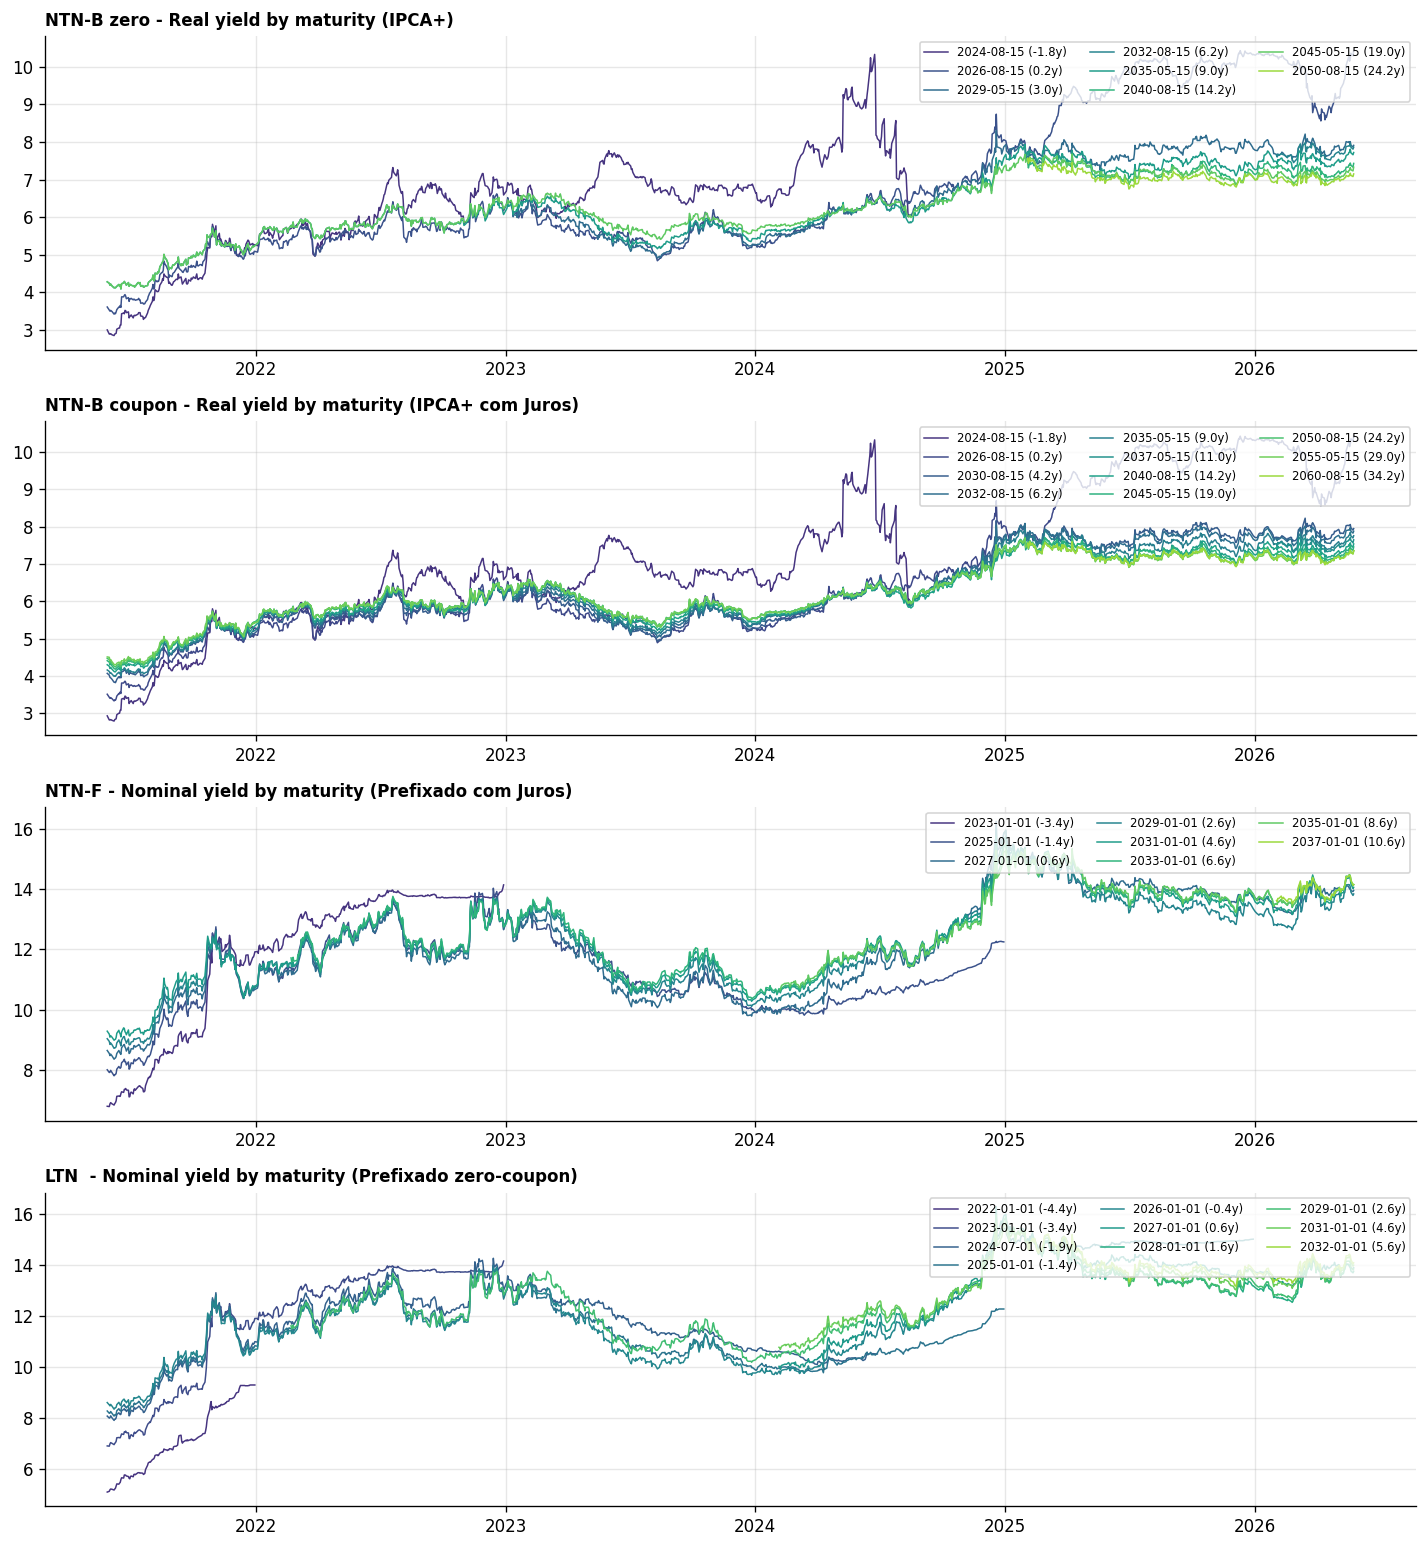

In [6]:
TITLES = {
    'ntnb_zero': 'NTN-B zero - Real yield by maturity (IPCA+)',
    'ntnb_coupon': 'NTN-B coupon - Real yield by maturity (IPCA+ com Juros)',
    'ntnf':'NTN-F - Nominal yield by maturity (Prefixado com Juros)',
    'ltn': 'LTN  - Nominal yield by maturity (Prefixado zero-coupon)',
}

fig, axes = plt.subplots(4, 1, figsize=(12, 13))

for ax, name in zip(axes, BOND_TYPES):
    df    = data[name]
    valid = df[df['is_valid']]
    mats  = valid['maturity'].drop_duplicates().sort_values()
    palette = cm.viridis(np.linspace(0.15, 0.85, len(mats)))

    for mat, color in zip(mats, palette):
        subset = valid[valid['maturity'] == mat].sort_values('date')
        ttm    = round((mat - today).days / 365, 1)
        ax.plot(subset['date'], subset['rate_annual'],
                color=color, linewidth=0.9, label=f"{mat.date()} ({ttm}y)")

    ax.set_title(TITLES[name], loc='left', fontweight='bold', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=7, ncol=3, loc='upper right')

plt.tight_layout()
plt.savefig('tesouro_yields_by_maturity.png', bbox_inches='tight')
plt.show()

### ntnb_zero vs ntnb_coupon

Both instruments have identical yields for the same maturity date
but very different PU values because coupon cash flows change the price.
This confirms they must be bootstrapped separately.

### Breakeven inflation : LTN vs ntnb_zero

Implied inflation = market's expectation embedded in the spread
between nominal (LTN) and real (NTN-B zero) yields.
Uses Fisher equation: (1 + nominal) / (1 + real) - 1.

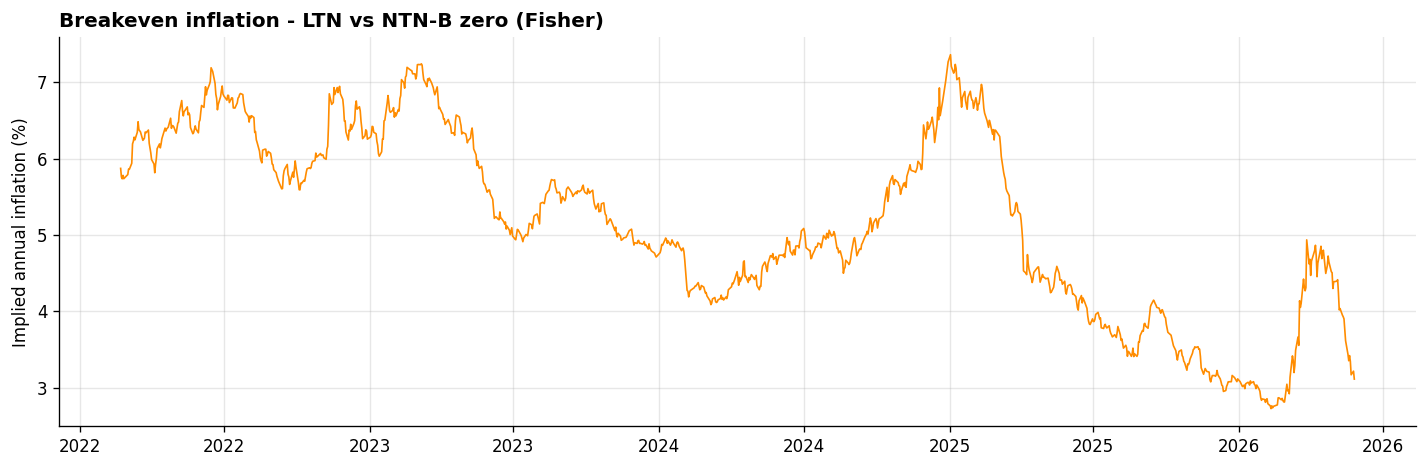

Latest breakeven: 3.11%
5yr mean: 5.18%
5yr range: 2.73% – 7.36%


In [7]:
ntnb = data['ntnb_zero'][data['ntnb_zero']['is_valid']].copy()
ltn  = data['ltn'][data['ltn']['is_valid']].copy()

# shortest active maturity per date as short-end proxy
def shortest_active(df):
    return (
        df[df['maturity'] > today]
        .assign(ttm=(df['maturity'] - today).dt.days)
        .loc[lambda d: d.groupby('date')['ttm'].idxmin()]
        [['date', 'rate_annual']]
    )

ntnb_s = shortest_active(ntnb).rename(columns={'rate_annual': 'real_rate'})
ltn_s  = shortest_active(ltn).rename(columns={'rate_annual': 'nom_rate'})

merged = ntnb_s.merge(ltn_s, on='date', how='inner')
merged['breakeven'] = (
    (1 + merged['nom_rate'] / 100) / (1 + merged['real_rate'] / 100) - 1
) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(merged['date'], merged['breakeven'], color='darkorange', linewidth=1.0)
ax.set_title('Breakeven inflation - LTN vs NTN-B zero (Fisher)', loc='left', fontweight='bold')
ax.set_ylabel('Implied annual inflation (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(f"Latest breakeven: {merged['breakeven'].iloc[-1]:.2f}%")
print(f"5yr mean: {merged['breakeven'].mean():.2f}%")
print(f"5yr range: {merged['breakeven'].min():.2f}% – {merged['breakeven'].max():.2f}%")

### PU base over time — NTN-B zero

PU grows as IPCA accrues into VNA. Falling PU on a fixed maturity = rising yield.
Side-by-side confirms inverse price-yield relationship before bootstrapping.

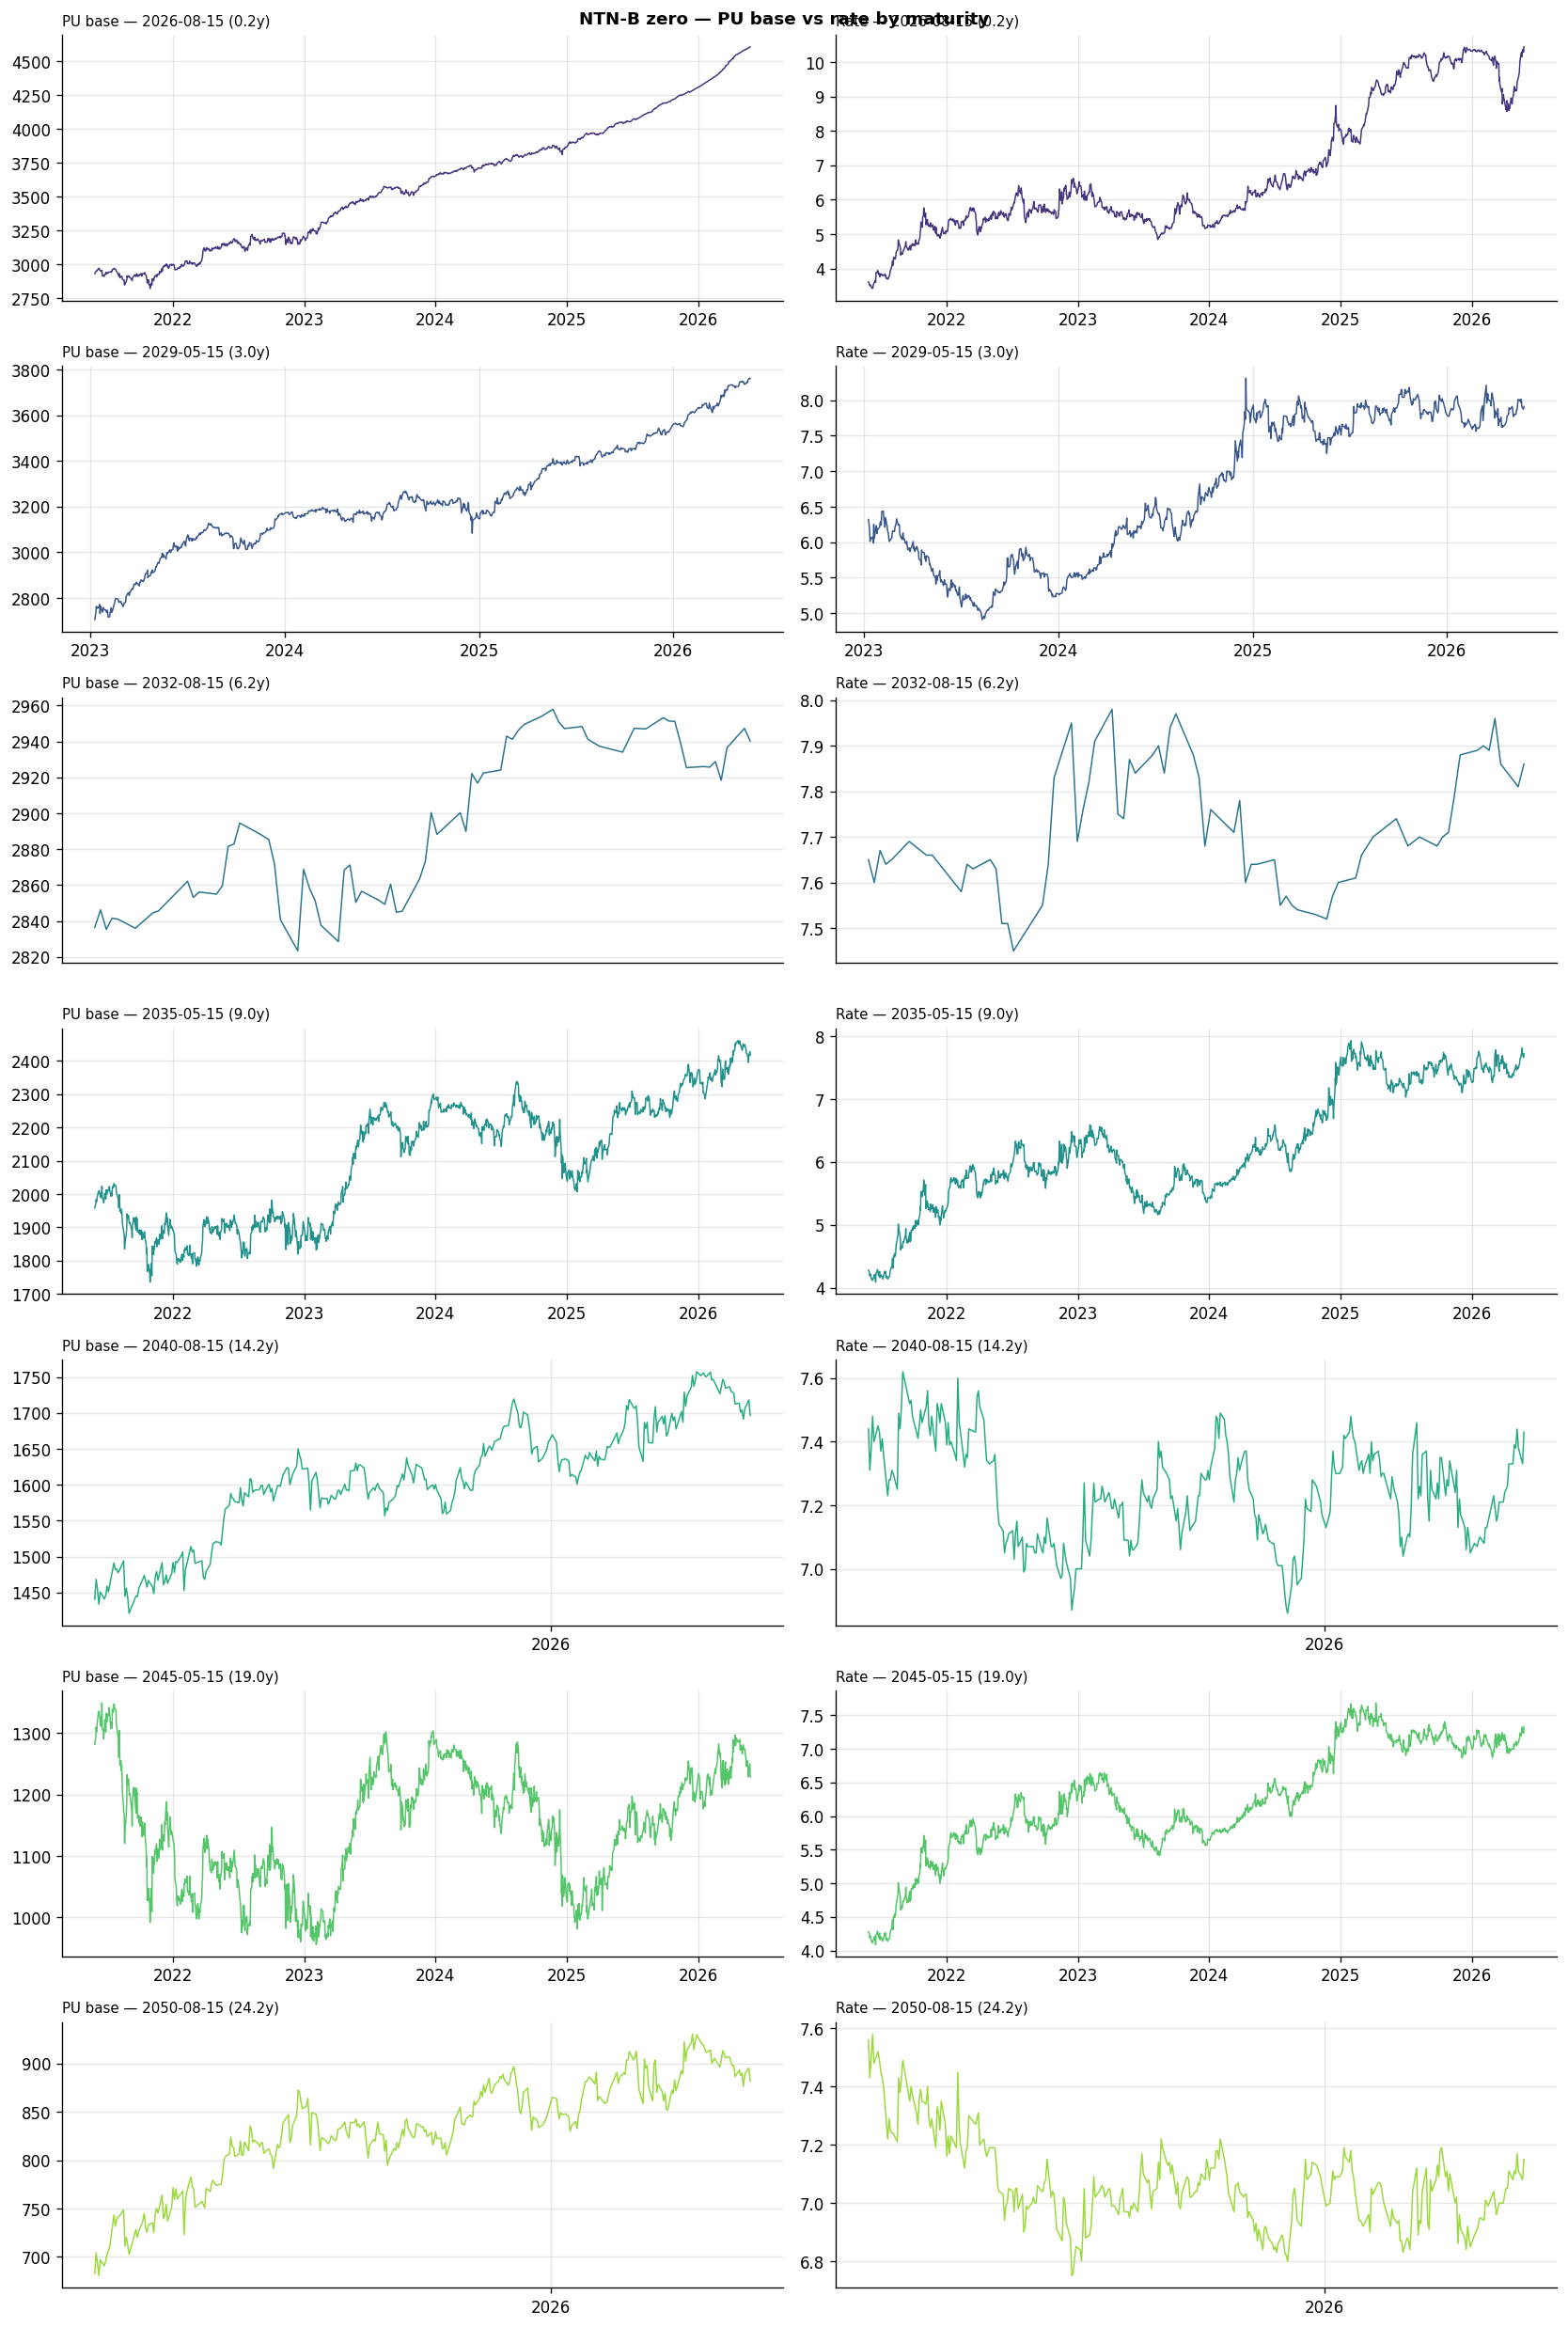

In [8]:
ntnb = data['ntnb_zero'][data['ntnb_zero']['is_valid']].copy()
active_mats = (
    ntnb[ntnb['maturity'] > today]['maturity']
    .drop_duplicates().sort_values()
)

fig, axes = plt.subplots(len(active_mats), 2, figsize=(14, 3 * len(active_mats)))
if len(active_mats) == 1:
    axes = [axes]

palette = cm.viridis(np.linspace(0.15, 0.85, len(active_mats)))

for (ax_pu, ax_rate), mat, color in zip(axes, active_mats, palette):
    subset = ntnb[ntnb['maturity'] == mat].sort_values('date')
    ttm    = round((mat - today).days / 365, 1)

    ax_pu.plot(subset['date'], subset['pu_base'], color=color, linewidth=0.9)
    ax_rate.plot(subset['date'], subset['rate_annual'], color=color, linewidth=0.9)

    ax_pu.set_title(f"PU base — {mat.date()} ({ttm}y)", fontsize=9, loc='left')
    ax_rate.set_title(f"Rate — {mat.date()} ({ttm}y)", fontsize=9, loc='left')

    for ax in (ax_pu, ax_rate):
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('NTN-B zero — PU base vs rate by maturity', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('ntnb_zero_pu_vs_rate.png', bbox_inches='tight')
plt.show()

### Gap Detection

In [9]:
for name, df in data.items():
    valid = df[df['is_valid']]
    for mat in valid['maturity'].unique():
        subset = valid[valid['maturity'] == mat].sort_values('date')
        if len(subset) < 10:
            continue
        bday_range = pd.bdate_range(subset['date'].min(), subset['date'].max())
        missing    = set(bday_range) - set(subset['date'])
        if missing:
            print(f"{name} // {mat.date()} // {len(missing)} missing business days")

print("Gap check complete.")

ntnb_zero // 2024-08-15 // 36 missing business days
ntnb_zero // 2026-08-15 // 58 missing business days
ntnb_zero // 2029-05-15 // 40 missing business days
ntnb_zero // 2032-08-15 // 5 missing business days
ntnb_zero // 2035-05-15 // 58 missing business days
ntnb_zero // 2040-08-15 // 16 missing business days
ntnb_zero // 2045-05-15 // 58 missing business days
ntnb_zero // 2050-08-15 // 16 missing business days
ntnb_coupon // 2024-08-15 // 36 missing business days
ntnb_coupon // 2026-08-15 // 58 missing business days
ntnb_coupon // 2030-08-15 // 58 missing business days
ntnb_coupon // 2032-08-15 // 50 missing business days
ntnb_coupon // 2035-05-15 // 58 missing business days
ntnb_coupon // 2037-05-15 // 5 missing business days
ntnb_coupon // 2040-08-15 // 58 missing business days
ntnb_coupon // 2045-05-15 // 58 missing business days
ntnb_coupon // 2050-08-15 // 58 missing business days
ntnb_coupon // 2055-05-15 // 58 missing business days
ntnb_coupon // 2060-08-15 // 16 missing busine